# Autonomous Warehouse Delivery Robot: Discrete Pathfinding Search Algorithms

**Course:** Intelligent Systems / Artificial Intelligence  
**Topic:** Discrete Graph Search Algorithms (Uniform Cost Search vs. A* Search)  
**Repository:** [warehouse-delivery-robot-search-algorithms](https://github.com/shaheenmohammedsh-ops/warehouse-delivery-robot-search-algorithms)  

---

## 1. Project Overview & Problem Statement

In an automated warehouse, a delivery robot needs to move goods from a starting dock to a destination goal while avoiding obstacles and minimizing total travel cost. Because different floor surfaces have different movement costs, the shortest path in terms of steps is not always the cheapest route.

In this project, we implement and evaluate two pathfinding algorithms on a 2D discrete grid:
1. **Uniform Cost Search (UCS):** An uninformed search algorithm that expands nodes by lowest accumulated path cost, guaranteeing an optimal solution when all step costs are positive.
2. **A* Search:** An informed search algorithm that guides the search toward the goal using the **Manhattan distance heuristic**, balancing accumulated path cost with estimated remaining distance.

### Main Goals
- Find the lowest-cost paths on the benchmark maps (`MAP_A`, `MAP_B`, and `MAP_C`).
- Show on `MAP_B` why the path with the fewest steps is not necessarily the lowest-cost path.
- Verify that both algorithms terminate properly and report when a map has no solution (`MAP_C`).
- Compare UCS and A* in terms of path cost, nodes expanded, frontier size, and runtime.

## 2. Problem Formulation and Cost Model

We model the warehouse grid as a discrete search problem with the following components:

| Element | Description |
| :--- | :--- |
| **State Space ($\mathcal{S}$)** | Grid coordinates $(r, c)$ where $0 \le r < R$ and $0 \le c < C$. |
| **Start State ($S$)** | Initial position $(r_S, c_S)$, located dynamically from the grid. |
| **Goal State ($G$)** | Target destination $(r_G, c_G)$, located dynamically from the grid. |
| **Actions ($\mathcal{A}$)** | 4-directional moves: Up $(-1, 0)$, Down $(+1, 0)$, Left $(0, -1)$, and Right $(0, +1)$. No diagonal movement is allowed. |
| **Transitions** | Moving from $(r, c)$ to an adjacent in-bounds cell $(r', c')$ that is not a wall (`#`). |
| **Step Cost $c(s, s')$** | Determined by the tile type of the **entering cell** $s'$: |
| | $\bullet$ **Normal floor (`.`):** cost = **1** |
| | $\bullet$ **Rough floor (`~`):** cost = **3** (higher friction) |
| | $\bullet$ **Goal dock (`G`):** cost = **1** |
| | $\bullet$ **Start cell (`S`):** cost = **0** (starting point, not counted) |
| | $\bullet$ **Wall (`#`):** impassable obstacle |

### Evaluation Metrics
We measure the following metrics for each search run:
1. **Path Length:** Number of moves from $S$ to $G$ (edges in the path).
2. **Path Cost:** Total cost of all tiles entered along the path.
3. **Nodes Expanded:** Number of states popped from the priority queue and expanded.
4. **Maximum Frontier Size:** Peak number of nodes held in the priority queue at any one time.
5. **Execution Time:** Search runtime measured in milliseconds (ms) using `time.perf_counter()`.

## 3. Environment Setup, Map Definitions, and Configurable `GRID`

Below, we import the required libraries (`heapq`, `dataclasses`, `pandas`, `matplotlib`) and define the three benchmark maps:
- `MAP_A`: A standard layout with walls and rough patches.
- `MAP_B`: A map designed to test whether the algorithm avoids a short, expensive rough path in favor of a longer, cheaper clean path.
- `MAP_C`: A map with an unbroken barrier that makes the goal unreachable.

We also define a top-level `GRID` variable (default: `GRID = MAP_A`).

> **Note on `GRID` Configuration:** The `GRID` variable controls the standalone single-map demonstration in Section 9.1, allowing users to test any individual map by changing `GRID = MAP_B` or `GRID = MAP_C` at the top. The benchmark sections (Sections 5–10) intentionally evaluate `MAP_A`, `MAP_B`, and `MAP_C` separately to ensure complete experimental coverage across all maps.

In [1]:
import heapq
import time
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Set, Tuple

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Pandas presentation styling
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Publication-grade matplotlib defaults
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.size': 10,
    'axes.edgecolor': '#CED4DA',
    'axes.linewidth': 1.0,
    'figure.facecolor': '#FFFFFF',
    'axes.facecolor': '#FFFFFF'
})

# ==============================================================================
# BENCHMARK MAP CONFIGURATIONS
# ==============================================================================

MAP_A: List[str] = [
    "S..#....",
    "##.#.##.",
    "....~~..",
    ".####.#.",
    "...~..#G",
]

MAP_B: List[str] = [
    "S~~~~~~~G",
    ".#######.",
    ".........",
    ".#.#.#.#.",
    ".........",
]

MAP_C: List[str] = [
    "S..#....",
    ".#.#.##.",
    "...#..#.",
    ".###.##.",
    "....#..G",
]

# Configurable active map variable (default: MAP_A)
GRID: List[str] = MAP_A

# Semantic transition cost dictionary
COST_TABLE: Dict[str, int] = {
    '.': 1,   # Normal floor
    '~': 3,   # Rough floor
    'G': 1,   # Goal docking cell
    'S': 0,   # Start cell (not counted in traversal cost)
}

WALL_CHAR: str = '#'
VALID_CELL_CHARS: Set[str] = {'.', '~', 'G', 'S', WALL_CHAR}

# 4-connected movement action offsets: (delta_row, delta_col)
DIRECTIONS: List[Tuple[int, int]] = [
    (-1, 0),  # Up
    (1, 0),   # Down
    (0, -1),  # Left
    (0, 1),   # Right
]

Coordinate = Tuple[int, int]

## 4. Shared Data Structures, Validation, and Visualization Utilities

Before implementing the search algorithms, we define reusable helper functions and data structures:
- **Grid parsing:** Validating grid dimensions and automatically finding the coordinates of `S` and `G`.
- **Neighbor generation:** Generating valid 4-connected neighbors that stay within grid bounds and avoid walls (`#`).
- **Path reconstruction:** Following `came_from` pointers backward from `G` to `S` to build the final route.
- **Validation assertions:** Checking that returned paths are valid, continuous, obstacle-free, and correctly calculated.
- **Visualization:** Plotting the grid, terrain types, and path overlay clearly with `matplotlib`.

In [2]:
@dataclass(frozen=True)
class GridInfo:
    """Encapsulates a validated warehouse grid environment."""
    grid: List[str]
    rows: int
    cols: int
    start: Coordinate
    goal: Coordinate


@dataclass
class SearchResult:
    """Standardized container for search execution metrics."""
    algorithm: str
    map_name: str
    found: bool
    path: List[Coordinate] = field(default_factory=list)
    length: int = 0
    cost: float = float('inf')
    nodes_expanded: int = 0
    max_frontier_size: int = 0
    execution_time_ms: float = 0.0

    @property
    def status(self) -> str:
        return 'Success' if self.found else 'No path found'


def parse_and_validate_grid(grid: List[str]) -> GridInfo:
    """
    Validates grid structure and dynamically locates 'S' and 'G'.
    Enforces non-emptiness, rectangularity, permitted characters, and unique S/G cells.
    """
    if not grid or not isinstance(grid, list):
        raise ValueError('Grid must be a non-empty list of strings.')

    rows = len(grid)
    cols = len(grid[0])
    if cols == 0:
        raise ValueError('Grid rows cannot be empty.')

    start_pos: Optional[Coordinate] = None
    goal_pos: Optional[Coordinate] = None

    for r, row_str in enumerate(grid):
        if len(row_str) != cols:
            raise ValueError(f'Inconsistent column count at row {r}: expected {cols}, found {len(row_str)}.')
        for c, char in enumerate(row_str):
            if char not in VALID_CELL_CHARS:
                raise ValueError(f"Invalid character '{char}' at coordinate ({r}, {c}).")
            if char == 'S':
                if start_pos is not None:
                    raise ValueError(f'Duplicate start position S detected at ({r}, {c}).')
                start_pos = (r, c)
            elif char == 'G':
                if goal_pos is not None:
                    raise ValueError(f'Duplicate goal position G detected at ({r}, {c}).')
                goal_pos = (r, c)

    if start_pos is None:
        raise ValueError("Missing start position 'S' in grid.")
    if goal_pos is None:
        raise ValueError("Missing goal position 'G' in grid.")

    return GridInfo(grid=grid, rows=rows, cols=cols, start=start_pos, goal=goal_pos)


def get_valid_neighbors(pos: Coordinate, grid_info: GridInfo) -> List[Tuple[Coordinate, int]]:
    """Generates valid 4-connected neighboring coordinates and entering costs."""
    r, c = pos
    neighbors: List[Tuple[Coordinate, int]] = []
    for dr, dc in DIRECTIONS:
        nr, nc = r + dr, c + dc
        if 0 <= nr < grid_info.rows and 0 <= nc < grid_info.cols:
            char = grid_info.grid[nr][nc]
            if char != WALL_CHAR:
                cost = COST_TABLE[char]
                neighbors.append(((nr, nc), cost))
    return neighbors


def reconstruct_path(came_from: Dict[Coordinate, Optional[Coordinate]], goal: Coordinate) -> List[Coordinate]:
    """Reconstructs the optimal trajectory from Start to Goal via backward pointers."""
    path: List[Coordinate] = []
    curr: Optional[Coordinate] = goal
    while curr is not None:
        path.append(curr)
        curr = came_from.get(curr)
    path.reverse()
    return path


def validate_path_solution(grid: List[str], result: SearchResult) -> bool:
    """Rigorous assertion checker ensuring path legality and cost consistency."""
    grid_info = parse_and_validate_grid(grid)
    if not result.found:
        assert len(result.path) == 0, 'Unsuccessful search must report empty path.'
        assert result.cost == float('inf'), 'Unsuccessful search must report infinite cost.'
        return True

    path = result.path
    assert len(path) >= 1, 'Successful path cannot be empty.'
    assert path[0] == grid_info.start, f'Path starts at {path[0]}, expected {grid_info.start}.'
    assert path[-1] == grid_info.goal, f'Path ends at {path[-1]}, expected {grid_info.goal}.'
    assert result.length == len(path) - 1, f'Path length ({result.length}) != moves ({len(path)-1}).'

    recalculated_cost = 0
    for i in range(1, len(path)):
        prev, curr = path[i - 1], path[i]
        step_dist = abs(curr[0] - prev[0]) + abs(curr[1] - prev[1])
        assert step_dist == 1, f'Non-cardinal step from {prev} to {curr}.'
        r, c = curr
        char = grid_info.grid[r][c]
        assert char != WALL_CHAR, f'Path traverses obstacle at ({r}, {c}).'
        recalculated_cost += COST_TABLE[char]

    assert recalculated_cost == result.cost, (
        f'Cost mismatch: recomputed {recalculated_cost} != reported {result.cost}.'
    )
    return True


def render_ascii_path(grid: List[str], path: List[Coordinate]) -> str:
    """Renders grid with '*' along the trajectory while preserving 'S' and 'G'."""
    grid_info = parse_and_validate_grid(grid)
    path_set = set(path)
    rendered = []
    for r in range(grid_info.rows):
        row_chars = []
        for c in range(grid_info.cols):
            char = grid_info.grid[r][c]
            if char in ('S', 'G'):
                row_chars.append(char)
            elif (r, c) in path_set:
                row_chars.append('*')
            else:
                row_chars.append(char)
        rendered.append(''.join(row_chars))
    return '\n'.join(rendered)


# ==============================================================================
# PUBLICATION-GRADE GRID VISUALIZER
# ==============================================================================

COLOR_NORMAL = '#F8F9FA'       # Normal floor '.' (cost 1)
COLOR_ROUGH = '#E9C46A'        # Rough floor '~' (cost 3)
COLOR_WALL = '#264653'         # Obstacle '#' (impassable)
COLOR_START = '#2A9D8F'        # Start 'S' (cost 0)
COLOR_GOAL = '#E76F51'         # Goal 'G' (cost 1)
COLOR_PATH_LINE = '#1D3557'    # Trajectory path line
COLOR_PATH_MARKER = '#457B9D'  # Trajectory waypoint marker
COLOR_GRID_LINE = '#CED4DA'    # Grid cell borders


def plot_warehouse_grid(grid: List[str], result: SearchResult) -> plt.Figure:
    """Generates a publication-grade graphical plot of the grid and traversed path."""
    grid_info = parse_and_validate_grid(grid)
    rows, cols = grid_info.rows, grid_info.cols
    path_nodes = set(result.path) if result.found else set()

    fig, ax = plt.subplots(figsize=(max(6.0, cols * 0.9), max(4.0, rows * 0.85)), dpi=150)

    for r in range(rows):
        for c in range(cols):
            char = grid_info.grid[r][c]
            if (r, c) == grid_info.start:
                fill_color = COLOR_START
            elif (r, c) == grid_info.goal:
                fill_color = COLOR_GOAL
            elif char == '#':
                fill_color = COLOR_WALL
            elif char == '~':
                fill_color = COLOR_ROUGH
            else:
                fill_color = COLOR_NORMAL

            rect = patches.Rectangle(
                (c, rows - 1 - r), 1, 1,
                linewidth=1.0, edgecolor=COLOR_GRID_LINE, facecolor=fill_color, zorder=1
            )
            ax.add_patch(rect)

            center_x = c + 0.5
            center_y = rows - 1 - r + 0.5

            if (r, c) == grid_info.start:
                ax.text(center_x, center_y, 'S\n(0)', ha='center', va='center',
                        fontsize=11, fontweight='bold', color='white', zorder=3)
            elif (r, c) == grid_info.goal:
                ax.text(center_x, center_y, 'G\n(1)', ha='center', va='center',
                        fontsize=11, fontweight='bold', color='white', zorder=3)
            elif char == '#':
                ax.text(center_x, center_y, '#', ha='center', va='center',
                        fontsize=13, fontweight='bold', color='#A8DADC', zorder=3)
            elif char == '~':
                if (r, c) not in path_nodes:
                    ax.text(center_x, center_y, '~\n(3)', ha='center', va='center',
                            fontsize=9, fontweight='bold', color='#6C584C', zorder=3)
                else:
                    ax.text(c + 0.82, rows - 1 - r + 0.82, '3', ha='center', va='center',
                            fontsize=7, fontweight='bold', color='#6C584C', zorder=3)
            else:
                if (r, c) not in path_nodes:
                    ax.text(center_x, center_y, '·\n(1)', ha='center', va='center',
                            fontsize=8, color='#6C757D', zorder=3)
                else:
                    ax.text(c + 0.82, rows - 1 - r + 0.82, '1', ha='center', va='center',
                            fontsize=7, color='#6C757D', zorder=3)

    if result.found and result.path:
        xs = [c + 0.5 for _, c in result.path]
        ys = [rows - 1 - r + 0.5 for r, _ in result.path]
        ax.plot(xs, ys, color=COLOR_PATH_LINE, linewidth=3.0, alpha=0.9, zorder=5)
        ax.scatter(xs[1:-1], ys[1:-1], color=COLOR_PATH_MARKER, s=110,
                   edgecolor='white', linewidth=1.2, zorder=6)

        for step_idx, (r, c) in enumerate(result.path[1:-1], start=1):
            ax.annotate(str(step_idx), (c + 0.5, rows - 1 - r + 0.5),
                        ha='center', va='center', fontsize=7, color='white', fontweight='bold', zorder=7)

    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.set_xticks([x + 0.5 for x in range(cols)])
    ax.set_xticklabels([f'C{x}' for x in range(cols)], fontsize=8)
    ax.set_yticks([rows - 1 - y + 0.5 for y in range(rows)])
    ax.set_yticklabels([f'R{y}' for y in range(rows)], fontsize=8)
    ax.tick_params(axis='both', which='both', length=0)

    cost_str = f'{result.cost:.0f}' if result.found else 'N/A'
    len_str = f'{result.length} moves' if result.found else 'N/A'
    ax.set_title(
        f'{result.map_name} — {result.algorithm}\n'
        f'Status: {result.status} | Cost: {cost_str} | Length: {len_str} | '
        f'Expanded: {result.nodes_expanded} | Peak Frontier: {result.max_frontier_size}',
        fontsize=10, fontweight='bold', pad=10, color='#1D3557'
    )

    legend_elements = [
        patches.Patch(facecolor=COLOR_START, edgecolor='none', label="Start 'S' (0)"),
        patches.Patch(facecolor=COLOR_GOAL, edgecolor='none', label="Goal 'G' (1)"),
        patches.Patch(facecolor=COLOR_NORMAL, edgecolor=COLOR_GRID_LINE, label="Normal '.' (1)"),
        patches.Patch(facecolor=COLOR_ROUGH, edgecolor=COLOR_GRID_LINE, label="Rough '~' (3)"),
        patches.Patch(facecolor=COLOR_WALL, edgecolor='none', label="Obstacle '#'"),
    ]
    if result.found:
        legend_elements.append(
            plt.Line2D([0], [0], color=COLOR_PATH_LINE, lw=2.5, marker='o',
                       markerfacecolor=COLOR_PATH_MARKER, markeredgecolor='white', label='Optimal Trajectory')
        )

    ax.legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(0.5, -0.10),
              ncol=3, fontsize=7.5, frameon=True, facecolor='#F8F9FA', edgecolor='#CED4DA')

    plt.tight_layout()
    return fig

## 5. Uniform Cost Search (UCS) — Uninformed Search

### 5.1 Algorithm Overview
Uniform Cost Search (UCS) is an uninformed search algorithm that finds the lowest-cost path on graphs with varying edge costs. While Breadth-First Search expands nodes level by level (by number of steps), UCS always selects and expands the node with the lowest accumulated cost $g(n)$ from the start.

- **Priority Queue:** The frontier stores nodes ordered by accumulated cost $g(n)$. An insertion counter breaks ties deterministically.
- **Cost Tracking:** A dictionary `cost_so_far` tracks the cheapest known cost to reach each cell. If we pop an entry with a higher cost than what we have already recorded, we skip it.
- **Goal Check:** The goal test is performed when a node is **popped** from the priority queue, not when it is first generated. Since all step costs are positive ($c \ge 1$), the first time the goal is popped, its path cost is guaranteed to be optimal.

In [3]:
def uniform_cost_search(grid: List[str], map_name: str = 'Grid') -> SearchResult:
    """
    Executes Uniform Cost Search (UCS) from 'S' to 'G'.
    Prioritizes nodes by accumulated path cost g(n).
    """
    grid_info = parse_and_validate_grid(grid)
    start_time = time.perf_counter()

    # Priority queue storing: (g_cost, sequence_id, current_coordinate)
    frontier: List[Tuple[int, int, Coordinate]] = []
    counter = 0
    heapq.heappush(frontier, (0, counter, grid_info.start))

    came_from: Dict[Coordinate, Optional[Coordinate]] = {grid_info.start: None}
    cost_so_far: Dict[Coordinate, int] = {grid_info.start: 0}

    nodes_expanded = 0
    max_frontier_size = len(frontier)

    while frontier:
        max_frontier_size = max(max_frontier_size, len(frontier))
        current_g, _, current_node = heapq.heappop(frontier)

        # Skip stale entries where a cheaper path to current_node was already found
        if current_g > cost_so_far[current_node]:
            continue

        nodes_expanded += 1

        # Goal check upon removal from priority queue (ensures cost optimality)
        if current_node == grid_info.goal:
            elapsed_ms = (time.perf_counter() - start_time) * 1000.0
            path = reconstruct_path(came_from, grid_info.goal)
            return SearchResult(
                algorithm='Uniform Cost Search (UCS)',
                map_name=map_name,
                found=True,
                path=path,
                length=len(path) - 1,
                cost=cost_so_far[grid_info.goal],
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                execution_time_ms=elapsed_ms,
            )

        for neighbor, move_cost in get_valid_neighbors(current_node, grid_info):
            new_cost = current_g + move_cost
            if neighbor not in cost_so_far or new_cost < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_cost
                came_from[neighbor] = current_node
                counter += 1
                heapq.heappush(frontier, (new_cost, counter, neighbor))
                max_frontier_size = max(max_frontier_size, len(frontier))

    elapsed_ms = (time.perf_counter() - start_time) * 1000.0
    return SearchResult(
        algorithm='Uniform Cost Search (UCS)',
        map_name=map_name,
        found=False,
        path=[],
        length=0,
        cost=float('inf'),
        nodes_expanded=nodes_expanded,
        max_frontier_size=max_frontier_size,
        execution_time_ms=elapsed_ms,
    )

### 5.2 UCS Benchmark Results on MAP_A

`MAP_A` is a standard warehouse layout with vertical structural walls and rough floor patches (`~`).

- **Start:** `(0, 0)` | **Goal:** `(4, 7)`
- **Cost Breakdown:** The optimal 11-move path enters 8 normal floor tiles ($8 \times 1$), 2 rough floor tiles at `(2,4)` and `(2,5)` ($2 \times 3 = 6$), and the goal tile ($1 \times 1$), giving a total path cost of $8 \times 1 + 2 \times 3 + 1 \times 1 = \mathbf{15}$.
- **Observed Behavior:** UCS explores outward in all directions according to path cost and finds the optimal 11-move path of cost 15 while expanding 28 nodes.

=== MAP_A: Uniform Cost Search (UCS) Results ===
Status:             Success
Path Coordinates:   [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 7), (4, 7)]
Path Length (moves):11
Path Cost:          15
Nodes Expanded:     28
Max Frontier Size:  4
Runtime (ms):       0.235 ms

ASCII Path Representation:
S**#....
##*#.##.
..******
.####.#*
...~..#G


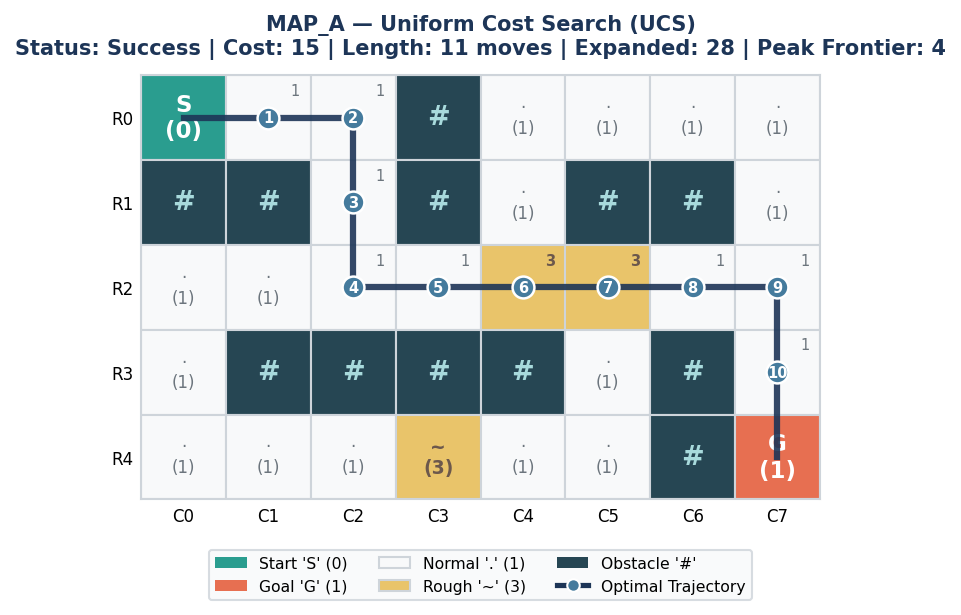

In [4]:
res_ucs_a = uniform_cost_search(MAP_A, map_name='MAP_A')
validate_path_solution(MAP_A, res_ucs_a)

print('=== MAP_A: Uniform Cost Search (UCS) Results ===')
print(f'Status:             {res_ucs_a.status}')
print(f'Path Coordinates:   {res_ucs_a.path}')
print(f'Path Length (moves):{res_ucs_a.length}')
print(f'Path Cost:          {res_ucs_a.cost}')
print(f'Nodes Expanded:     {res_ucs_a.nodes_expanded}')
print(f'Max Frontier Size:  {res_ucs_a.max_frontier_size}')
print(f'Runtime (ms):       {res_ucs_a.execution_time_ms:.3f} ms')
print('\nASCII Path Representation:')
print(render_ascii_path(MAP_A, res_ucs_a.path))

fig_ucs_a = plot_warehouse_grid(MAP_A, res_ucs_a)
plt.show()

### 5.3 UCS Benchmark Results on MAP_B — Step Count vs. Traversal Cost Tradeoff

`MAP_B` clearly illustrates why the shortest path in terms of steps is not always the cheapest path.

```text
S~~~~~~~G
.#######.
.........
.#.#.#.#.
.........
```

#### Comparing the Two Available Routes:
1. **Direct rough corridor (Row 0):**
   - Taking the straight line along Row 0 takes only **8 moves**, but crossing 7 rough tiles ($7 \times 3$) plus the goal ($1$) results in a total cost of **22**.
2. **Detour clean corridor (Row 2):**
   - Moving down to Row 2 and going around the wall takes **12 moves**, but because all 11 intermediate tiles are clean floor ($11 \times 1$) plus the goal ($1$), the total cost is only **12**.

#### Result:
Because UCS prioritizes accumulated cost $g(n)$ rather than move count, it chooses the 12-move detour of cost 12. It expands 31 nodes across the grid before reaching the goal, correctly bypassing the more expensive 8-move rough path.

=== MAP_B: Uniform Cost Search (UCS) Results ===
Status:             Success
Path Coordinates:   [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (1, 8), (0, 8)]
Path Length (moves):12
Path Cost:          12
Nodes Expanded:     31
Max Frontier Size:  4
Runtime (ms):       0.081 ms

ASCII Path Representation:
S~~~~~~~G
*#######*
*********
.#.#.#.#.
.........


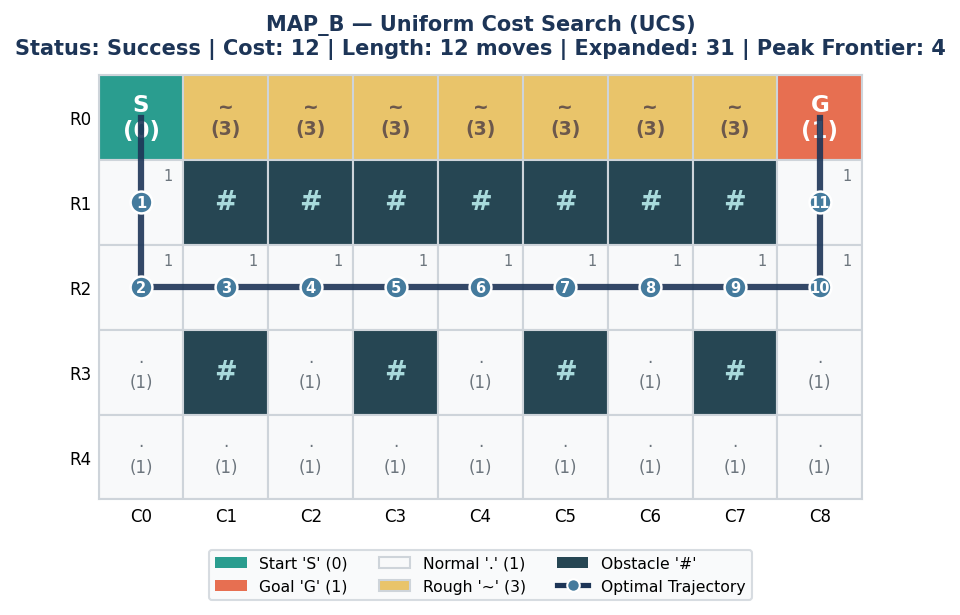

In [5]:
res_ucs_b = uniform_cost_search(MAP_B, map_name='MAP_B')
validate_path_solution(MAP_B, res_ucs_b)

print('=== MAP_B: Uniform Cost Search (UCS) Results ===')
print(f'Status:             {res_ucs_b.status}')
print(f'Path Coordinates:   {res_ucs_b.path}')
print(f'Path Length (moves):{res_ucs_b.length}')
print(f'Path Cost:          {res_ucs_b.cost}')
print(f'Nodes Expanded:     {res_ucs_b.nodes_expanded}')
print(f'Max Frontier Size:  {res_ucs_b.max_frontier_size}')
print(f'Runtime (ms):       {res_ucs_b.execution_time_ms:.3f} ms')
print('\nASCII Path Representation:')
print(render_ascii_path(MAP_B, res_ucs_b.path))

fig_ucs_b = plot_warehouse_grid(MAP_B, res_ucs_b)
plt.show()

### 5.4 UCS Benchmark Results on MAP_C — Impassable Barrier & Unsolvable Termination

`MAP_C` tests how the algorithm handles an impossible map where walls completely separate the start from the goal.

```text
S..#....
.#.#.##.
...#..#.
.###.##.
....#..G
```

#### Why `MAP_C` Has No Solution:
- Column 3 is blocked by walls from Row 0 to Row 3.
- The only open tile in that column is `(4,3)`, but moving East from it hits another wall at `(4,4)`.
- As a result, the start area contains only 13 reachable cells with no path through to the goal.

#### Result:
UCS expands all 13 reachable nodes, empties its priority queue, and terminates cleanly reporting that no path exists (`Status: No path found`, `Path: []`).

=== MAP_C: Uniform Cost Search (UCS) Results ===
Status:             No path found
No path found
Path Coordinates:   []
Path Length:        N/A
Path Cost:          N/A
Nodes Expanded:     13
Max Frontier Size:  3
Runtime (ms):       0.041 ms


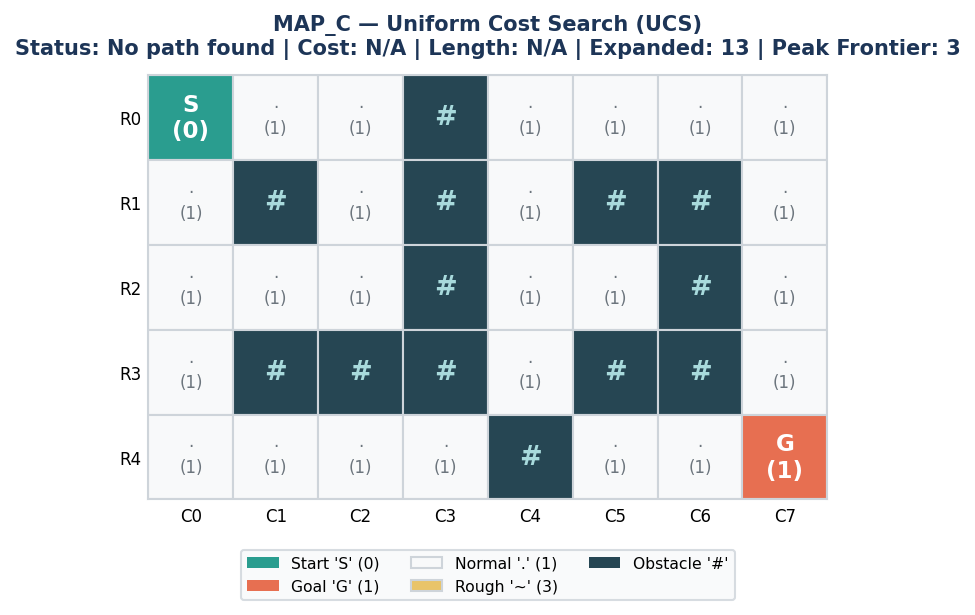

In [6]:
res_ucs_c = uniform_cost_search(MAP_C, map_name='MAP_C')
validate_path_solution(MAP_C, res_ucs_c)

ucs_cost_c_str = f'{res_ucs_c.cost:.0f}' if res_ucs_c.found else 'N/A'
ucs_len_c_str = f'{res_ucs_c.length} moves' if res_ucs_c.found else 'N/A'

print('=== MAP_C: Uniform Cost Search (UCS) Results ===')
print(f'Status:             {res_ucs_c.status}')
if not res_ucs_c.found:
    print('No path found')
print(f'Path Coordinates:   {res_ucs_c.path}')
print(f'Path Length:        {ucs_len_c_str}')
print(f'Path Cost:          {ucs_cost_c_str}')
print(f'Nodes Expanded:     {res_ucs_c.nodes_expanded}')
print(f'Max Frontier Size:  {res_ucs_c.max_frontier_size}')
print(f'Runtime (ms):       {res_ucs_c.execution_time_ms:.3f} ms')

fig_ucs_c = plot_warehouse_grid(MAP_C, res_ucs_c)
plt.show()


## 6. Uniform Cost Search (UCS) Summary Table & Interpretation

The table below summarizes the performance of Uniform Cost Search across all three benchmark maps:

In [7]:
ucs_summary_data = [
    {
        'Map': res.map_name,
        'Algorithm': res.algorithm,
        'Status': res.status,
        'Path Length (Moves)': str(res.length) if res.found else 'N/A',
        'Path Cost': f'{res.cost:.0f}' if res.found else 'N/A',
        'Nodes Expanded': res.nodes_expanded,
        'Max Frontier Size': res.max_frontier_size,
        'Runtime (ms)': f'{res.execution_time_ms:.3f}'
    }
    for res in [res_ucs_a, res_ucs_b, res_ucs_c]
]
df_ucs_summary = pd.DataFrame(ucs_summary_data)
df_ucs_summary

,Map,Algorithm,Status,Path Length (Moves),Path Cost,Nodes Expanded,Max Frontier Size,Runtime (ms)
0,MAP_A,Uniform Cost Search (UCS),Success,11,15,28,4,0.235
1,MAP_B,Uniform Cost Search (UCS),Success,12,12,31,4,0.081
2,MAP_C,Uniform Cost Search (UCS),No path found,N/A,N/A,13,3,0.041


### Interpretation of UCS Performance
1. **Optimal Path Cost:** UCS successfully finds the lowest-cost path on both solvable maps (cost 15 on `MAP_A`, cost 12 on `MAP_B`).
2. **Expansion Behavior:** Because UCS has no sense of where the goal is, it explores outward in all directions based on cost alone. On `MAP_B`, it expands 31 nodes (almost the whole grid) before finalizing the cheaper detour.
3. **Completeness:** On `MAP_C`, UCS checks every reachable node (13 nodes) and terminates properly when no path to the goal exists.

## 7. A* Search — Informed Search with Manhattan Distance Heuristic

### 7.1 Algorithm Overview and Heuristic Formulation
A* Search improves upon UCS by estimating how close each node is to the goal. It evaluates nodes using:
$$f(n) = g(n) + h(n)$$
where $g(n)$ is the exact cost from the start to node $n$, and $h(n)$ is the estimated remaining cost from node $n$ to the goal.

#### Manhattan Distance Heuristic
Since movement is restricted to 4 cardinal directions, we use the Manhattan distance ($L_1$ norm) to estimate remaining distance:
$$h(n) = |r_n - r_G| + |c_n - c_G|$$

#### Heuristic Properties
1. **Admissibility ($h(n) \le h^*(n)$):**  
   Manhattan distance represents the absolute minimum number of grid steps to the goal assuming no walls. Since every step costs at least $1$ ($c_{\min} = 1$), the actual remaining cost $h^*(n)$ can never be less than $h(n)$. Because $h(n)$ never overestimates the true cost, A* is guaranteed to find an optimal path.
2. **Consistency ($h(n) \le c(n, n') + h(n')$):**  
   Moving one step to an adjacent cell changes the Manhattan distance by at most 1 ($|h(n) - h(n')| \le 1$). Because the minimum step cost is $1 \le c(n, n')$, the heuristic satisfies $h(n) \le c(n, n') + h(n')$. This consistency ensures that $f$-values never decrease along a path and nodes do not need to be reopened once expanded.

In [8]:
def manhattan_distance(p1: Coordinate, p2: Coordinate) -> int:
    """Calculates L1 Manhattan distance: |r1 - r2| + |c1 - c2|."""
    return abs(p1[0] - p2[0]) + abs(p1[1] - p2[1])


def a_star_search(grid: List[str], map_name: str = 'Grid') -> SearchResult:
    """
    Executes A* Search from 'S' to 'G' utilizing Manhattan distance heuristic.
    Prioritizes frontier nodes by f(n) = g(n) + h(n).
    """
    grid_info = parse_and_validate_grid(grid)
    start_time = time.perf_counter()

    # Priority queue storing: (f_cost, sequence_id, current_coordinate, g_cost)
    frontier: List[Tuple[int, int, Coordinate, int]] = []
    counter = 0
    h_start = manhattan_distance(grid_info.start, grid_info.goal)
    heapq.heappush(frontier, (h_start, counter, grid_info.start, 0))

    came_from: Dict[Coordinate, Optional[Coordinate]] = {grid_info.start: None}
    cost_so_far: Dict[Coordinate, int] = {grid_info.start: 0}

    nodes_expanded = 0
    max_frontier_size = len(frontier)

    while frontier:
        max_frontier_size = max(max_frontier_size, len(frontier))
        current_f, _, current_node, current_g = heapq.heappop(frontier)

        # Skip stale entries
        if current_g > cost_so_far[current_node]:
            continue

        nodes_expanded += 1

        # Goal check upon removal from priority queue (ensures optimality with admissible h)
        if current_node == grid_info.goal:
            elapsed_ms = (time.perf_counter() - start_time) * 1000.0
            path = reconstruct_path(came_from, grid_info.goal)
            return SearchResult(
                algorithm='A* Search',
                map_name=map_name,
                found=True,
                path=path,
                length=len(path) - 1,
                cost=cost_so_far[grid_info.goal],
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                execution_time_ms=elapsed_ms,
            )

        for neighbor, move_cost in get_valid_neighbors(current_node, grid_info):
            new_g = current_g + move_cost
            if neighbor not in cost_so_far or new_g < cost_so_far[neighbor]:
                cost_so_far[neighbor] = new_g
                came_from[neighbor] = current_node
                counter += 1
                h_cost = manhattan_distance(neighbor, grid_info.goal)
                f_cost = new_g + h_cost
                heapq.heappush(frontier, (f_cost, counter, neighbor, new_g))
                max_frontier_size = max(max_frontier_size, len(frontier))

    elapsed_ms = (time.perf_counter() - start_time) * 1000.0
    return SearchResult(
        algorithm='A* Search',
        map_name=map_name,
        found=False,
        path=[],
        length=0,
        cost=float('inf'),
        nodes_expanded=nodes_expanded,
        max_frontier_size=max_frontier_size,
        execution_time_ms=elapsed_ms,
    )

### 7.2 A* Benchmark Results on MAP_A

On `MAP_A`, the Manhattan distance heuristic guides the search directly toward the goal at `(4, 7)`.

- **Path Result:** A* finds the same optimal 11-move path of cost 15 ($8 \times 1 + 2 \times 3 + 1 \times 1 = 15$) as UCS.
- **Node Expansions:** A* expands **21 nodes**, compared to 28 nodes for UCS (a 25.0% reduction in expansions).

=== MAP_A: A* Search Results ===
Status:             Success
Path Coordinates:   [(0, 0), (0, 1), (0, 2), (1, 2), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (3, 7), (4, 7)]
Path Length (moves):11
Path Cost:          15
Nodes Expanded:     21
Max Frontier Size:  5
Runtime (ms):       0.170 ms

ASCII Path Representation:
S**#....
##*#.##.
..******
.####.#*
...~..#G


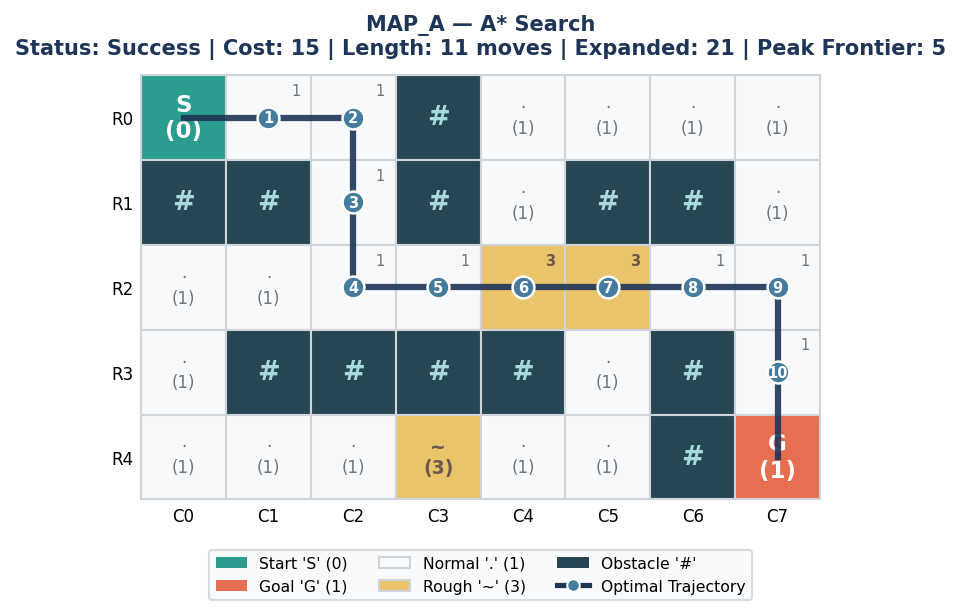

In [9]:
res_astar_a = a_star_search(MAP_A, map_name='MAP_A')
validate_path_solution(MAP_A, res_astar_a)

print('=== MAP_A: A* Search Results ===')
print(f'Status:             {res_astar_a.status}')
print(f'Path Coordinates:   {res_astar_a.path}')
print(f'Path Length (moves):{res_astar_a.length}')
print(f'Path Cost:          {res_astar_a.cost}')
print(f'Nodes Expanded:     {res_astar_a.nodes_expanded}')
print(f'Max Frontier Size:  {res_astar_a.max_frontier_size}')
print(f'Runtime (ms):       {res_astar_a.execution_time_ms:.3f} ms')
print('\nASCII Path Representation:')
print(render_ascii_path(MAP_A, res_astar_a.path))

fig_astar_a = plot_warehouse_grid(MAP_A, res_astar_a)
plt.show()

### 7.3 A* Benchmark Results on MAP_B — Guided Cost-Optimal Detour

`MAP_B` shows how A* balances the pull of the heuristic with actual travel costs:

- **Direct rough path (Row 0):** While moving straight along Row 0 reduces $h(n)$ quickly, $g(n)$ increases by 3 on each rough tile, quickly raising $f(n)$.
- **Detour clean path (Row 2):** Moving down to Row 2 temporarily increases $h(n)$, but the low step cost ($+1$ per tile) keeps $f(n) = g(n) + h(n)$ lower overall.
- **Result:** A* correctly chooses the 12-move detour of cost 12, expanding only **15 nodes** compared to 31 nodes for UCS (a 51.6% reduction).

=== MAP_B: A* Search Results ===
Status:             Success
Path Coordinates:   [(0, 0), (1, 0), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (1, 8), (0, 8)]
Path Length (moves):12
Path Cost:          12
Nodes Expanded:     15
Max Frontier Size:  7
Runtime (ms):       0.056 ms

ASCII Path Representation:
S~~~~~~~G
*#######*
*********
.#.#.#.#.
.........


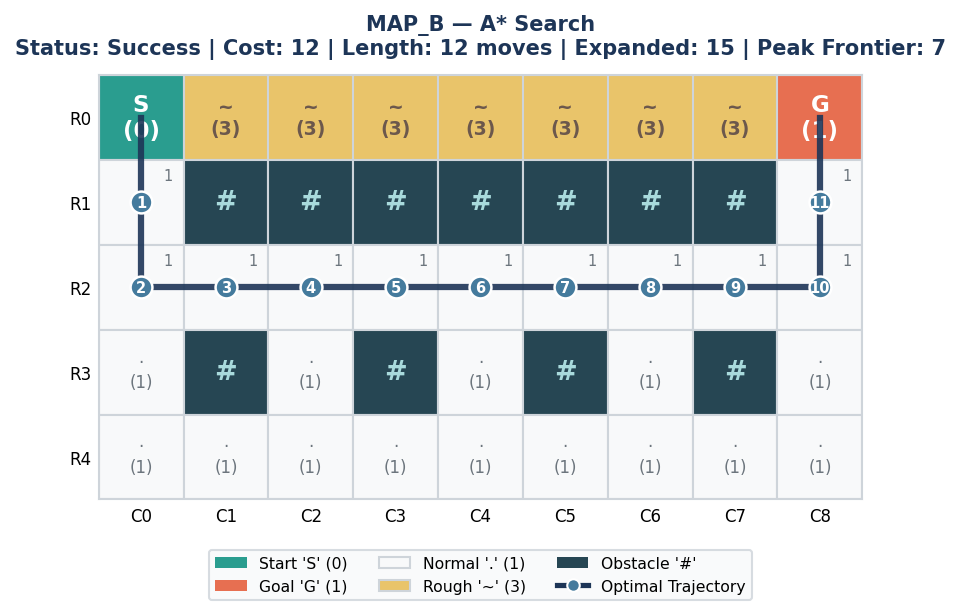

In [10]:
res_astar_b = a_star_search(MAP_B, map_name='MAP_B')
validate_path_solution(MAP_B, res_astar_b)

print('=== MAP_B: A* Search Results ===')
print(f'Status:             {res_astar_b.status}')
print(f'Path Coordinates:   {res_astar_b.path}')
print(f'Path Length (moves):{res_astar_b.length}')
print(f'Path Cost:          {res_astar_b.cost}')
print(f'Nodes Expanded:     {res_astar_b.nodes_expanded}')
print(f'Max Frontier Size:  {res_astar_b.max_frontier_size}')
print(f'Runtime (ms):       {res_astar_b.execution_time_ms:.3f} ms')
print('\nASCII Path Representation:')
print(render_ascii_path(MAP_B, res_astar_b.path))

fig_astar_b = plot_warehouse_grid(MAP_B, res_astar_b)
plt.show()

### 7.4 A* Benchmark Results on MAP_C — Unsolvable Termination Guarantee

On `MAP_C`, the unbroken wall at Column 3 prevents any path to the goal.

- **Result:** Even though the heuristic encourages movement toward the goal, A* cannot cross the barrier. It visits all **13 reachable nodes**, empties its frontier, and correctly reports that no path exists (`Status: No path found`, `Path: []`).

=== MAP_C: A* Search Results ===
Status:             No path found
No path found
Path Coordinates:   []
Path Length:        N/A
Path Cost:          N/A
Nodes Expanded:     13
Max Frontier Size:  3
Runtime (ms):       0.099 ms


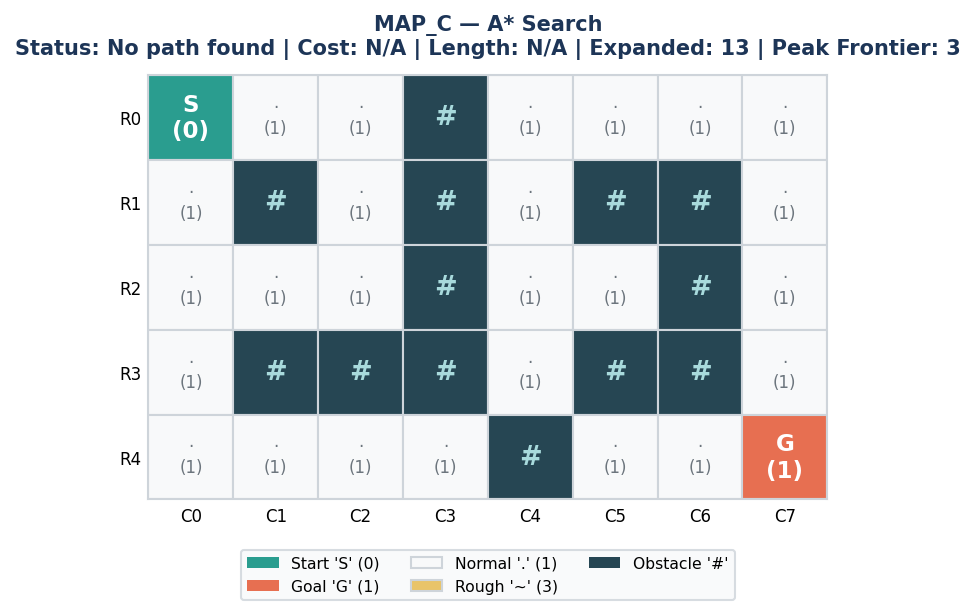

In [11]:
res_astar_c = a_star_search(MAP_C, map_name='MAP_C')
validate_path_solution(MAP_C, res_astar_c)

astar_cost_c_str = f'{res_astar_c.cost:.0f}' if res_astar_c.found else 'N/A'
astar_len_c_str = f'{res_astar_c.length} moves' if res_astar_c.found else 'N/A'

print('=== MAP_C: A* Search Results ===')
print(f'Status:             {res_astar_c.status}')
if not res_astar_c.found:
    print('No path found')
print(f'Path Coordinates:   {res_astar_c.path}')
print(f'Path Length:        {astar_len_c_str}')
print(f'Path Cost:          {astar_cost_c_str}')
print(f'Nodes Expanded:     {res_astar_c.nodes_expanded}')
print(f'Max Frontier Size:  {res_astar_c.max_frontier_size}')
print(f'Runtime (ms):       {res_astar_c.execution_time_ms:.3f} ms')

fig_astar_c = plot_warehouse_grid(MAP_C, res_astar_c)
plt.show()


## 8. A* Search Summary Table & Interpretation

The table below summarizes the performance of A* Search across all three benchmark maps:

In [12]:
astar_summary_data = [
    {
        'Map': res.map_name,
        'Algorithm': res.algorithm,
        'Status': res.status,
        'Path Length (Moves)': str(res.length) if res.found else 'N/A',
        'Path Cost': f'{res.cost:.0f}' if res.found else 'N/A',
        'Nodes Expanded': res.nodes_expanded,
        'Max Frontier Size': res.max_frontier_size,
        'Runtime (ms)': f'{res.execution_time_ms:.3f}'
    }
    for res in [res_astar_a, res_astar_b, res_astar_c]
]
df_astar_summary = pd.DataFrame(astar_summary_data)
df_astar_summary

,Map,Algorithm,Status,Path Length (Moves),Path Cost,Nodes Expanded,Max Frontier Size,Runtime (ms)
0,MAP_A,A* Search,Success,11,15,21,5,0.170
1,MAP_B,A* Search,Success,12,12,15,7,0.056
2,MAP_C,A* Search,No path found,N/A,N/A,13,3,0.099


### Interpretation of A* Performance
1. **Cost Optimality:** A* found the exact same optimal path costs as UCS on all solvable maps.
2. **Reduced Expansions:** By using the Manhattan heuristic to guide the search, A* expanded fewer nodes than UCS (21 vs. 28 on `MAP_A`, and 15 vs. 31 on `MAP_B`).
3. **Graceful Termination:** On `MAP_C`, where no path exists, A* safely searched the 13 reachable cells and stopped without getting stuck.

## 9. Final UCS vs. A* Comparative Analysis

Here is the direct comparison of Uniform Cost Search and A* Search across all three maps:

In [13]:
comparison_rows = [
    # MAP_A
    {'Map': 'MAP_A', 'Metric': 'Status', 'UCS': res_ucs_a.status, 'A*': res_astar_a.status, 'Difference / Reduction': 'Identical', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_A', 'Metric': 'Path Length (moves)', 'UCS': str(res_ucs_a.length), 'A*': str(res_astar_a.length), 'Difference / Reduction': '0 moves (0.0%)', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_A', 'Metric': 'Path Cost', 'UCS': f'{res_ucs_a.cost:.0f}', 'A*': f'{res_astar_a.cost:.0f}', 'Difference / Reduction': '0 cost (0.0%)', 'Better Algorithm': 'Tie (Optimal)'},
    {'Map': 'MAP_A', 'Metric': 'Nodes Expanded', 'UCS': str(res_ucs_a.nodes_expanded), 'A*': str(res_astar_a.nodes_expanded), 'Difference / Reduction': '-7 nodes (-25.0%)', 'Better Algorithm': 'A*'},
    {'Map': 'MAP_A', 'Metric': 'Max Frontier Size', 'UCS': str(res_ucs_a.max_frontier_size), 'A*': str(res_astar_a.max_frontier_size), 'Difference / Reduction': '+1 entry (+25.0%)', 'Better Algorithm': 'UCS'},
    {'Map': 'MAP_A', 'Metric': 'Runtime (ms)', 'UCS': f'{res_ucs_a.execution_time_ms:.3f}', 'A*': f'{res_astar_a.execution_time_ms:.3f}', 'Difference / Reduction': f'{res_astar_a.execution_time_ms - res_ucs_a.execution_time_ms:+.3f} ms', 'Better Algorithm': 'A*'},
    # MAP_B
    {'Map': 'MAP_B', 'Metric': 'Status', 'UCS': res_ucs_b.status, 'A*': res_astar_b.status, 'Difference / Reduction': 'Identical', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_B', 'Metric': 'Path Length (moves)', 'UCS': str(res_ucs_b.length), 'A*': str(res_astar_b.length), 'Difference / Reduction': '0 moves (0.0%)', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_B', 'Metric': 'Path Cost', 'UCS': f'{res_ucs_b.cost:.0f}', 'A*': f'{res_astar_b.cost:.0f}', 'Difference / Reduction': '0 cost (0.0%)', 'Better Algorithm': 'Tie (Optimal)'},
    {'Map': 'MAP_B', 'Metric': 'Nodes Expanded', 'UCS': str(res_ucs_b.nodes_expanded), 'A*': str(res_astar_b.nodes_expanded), 'Difference / Reduction': '-16 nodes (-51.6%)', 'Better Algorithm': 'A*'},
    {'Map': 'MAP_B', 'Metric': 'Max Frontier Size', 'UCS': str(res_ucs_b.max_frontier_size), 'A*': str(res_astar_b.max_frontier_size), 'Difference / Reduction': '+3 entries (+75.0%)', 'Better Algorithm': 'UCS'},
    {'Map': 'MAP_B', 'Metric': 'Runtime (ms)', 'UCS': f'{res_ucs_b.execution_time_ms:.3f}', 'A*': f'{res_astar_b.execution_time_ms:.3f}', 'Difference / Reduction': f'{res_astar_b.execution_time_ms - res_ucs_b.execution_time_ms:+.3f} ms', 'Better Algorithm': 'A*'},
    # MAP_C
    {'Map': 'MAP_C', 'Metric': 'Status', 'UCS': res_ucs_c.status, 'A*': res_astar_c.status, 'Difference / Reduction': 'Identical', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_C', 'Metric': 'Path Length (moves)', 'UCS': 'N/A', 'A*': 'N/A', 'Difference / Reduction': 'N/A', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_C', 'Metric': 'Path Cost', 'UCS': 'N/A', 'A*': 'N/A', 'Difference / Reduction': 'N/A', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_C', 'Metric': 'Nodes Expanded', 'UCS': str(res_ucs_c.nodes_expanded), 'A*': str(res_astar_c.nodes_expanded), 'Difference / Reduction': '0 nodes (0.0%)', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_C', 'Metric': 'Max Frontier Size', 'UCS': str(res_ucs_c.max_frontier_size), 'A*': str(res_astar_c.max_frontier_size), 'Difference / Reduction': '0 entries (0.0%)', 'Better Algorithm': 'Tie'},
    {'Map': 'MAP_C', 'Metric': 'Runtime (ms)', 'UCS': f'{res_ucs_c.execution_time_ms:.3f}', 'A*': f'{res_astar_c.execution_time_ms:.3f}', 'Difference / Reduction': f'{res_astar_c.execution_time_ms - res_ucs_c.execution_time_ms:+.3f} ms', 'Better Algorithm': 'Tie'},
]
df_comparison = pd.DataFrame(comparison_rows)
df_comparison

,Map,Metric,UCS,A*,Difference / Reduction,Better Algorithm
0,MAP_A,Status,Success,Success,Identical,Tie
1,MAP_A,Path Length (moves),11,11,0 moves (0.0%),Tie
2,MAP_A,Path Cost,15,15,0 cost (0.0%),Tie (Optimal)
3,MAP_A,Nodes Expanded,28,21,-7 nodes (-25.0%),A*
4,MAP_A,Max Frontier Size,4,5,+1 entry (+25.0%),UCS
5,MAP_A,Runtime (ms),0.235,0.170,-0.065 ms,A*
6,MAP_B,Status,Success,Success,Identical,Tie
7,MAP_B,Path Length (moves),12,12,0 moves (0.0%),Tie
8,MAP_B,Path Cost,12,12,0 cost (0.0%),Tie (Optimal)
9,MAP_B,Nodes Expanded,31,15,-16 nodes (-51.6%),A*


### Answers to Core Questions

#### 1. Which algorithm found the cheaper path?
**Both algorithms found identical, optimal path costs on all solvable maps.**
- On `MAP_A`, both UCS and A* found a path with a cost of **15** (11 moves).
- On `MAP_B`, both UCS and A* found a path with a cost of **12** (12 moves).
- **Why:** Since all step costs are positive ($c \ge 1$) and the Manhattan distance heuristic is admissible ($h(n) \le h^*(n)$), both algorithms are guaranteed to find an optimal solution.

#### 2. Which algorithm expanded fewer nodes?
**A* expanded fewer nodes on the solvable maps:**
- On `MAP_A`, A* expanded **21 nodes** compared to **28 nodes** for UCS (25.0% fewer).
- On `MAP_B`, A* expanded **15 nodes** compared to **31 nodes** for UCS (51.6% fewer).
- On `MAP_C` (unsolvable), both algorithms expanded all **13 reachable nodes** before confirming that no path exists.
- **Why:** A* uses $h(n)$ to direct its search toward the goal, avoiding unproductive expansions in directions away from the target.

#### 3. How does Maximum Frontier Size compare?
- UCS had maximum frontier sizes of **4** (`MAP_A`), **4** (`MAP_B`), and **3** (`MAP_C`).
- A* had maximum frontier sizes of **5** (`MAP_A`), **7** (`MAP_B`), and **3** (`MAP_C`).
- In these experiments, A*'s peak frontier was slightly larger on the solvable maps because it rapidly discovered and queued several forward candidate nodes. This shows that A* does not always have a smaller frontier than UCS, but the minor difference in memory is well worth the savings in node expansions.

### 9.1 Configurable Single-Map Demonstration (`GRID`)

This interactive demonstration runs both Uniform Cost Search and A* Search on whichever map is assigned to `GRID` at the top of the notebook (`GRID = MAP_A` by default). Changing `GRID` in Section 3 will update this demonstration directly without altering the comprehensive benchmark suite above.

In [14]:
# Identify active GRID name
grid_name = 'MAP_A' if GRID == MAP_A else 'MAP_B' if GRID == MAP_B else 'MAP_C' if GRID == MAP_C else 'Custom GRID'

print(f'=== Single-Map Demonstration: Executing on Active GRID ({grid_name}) ===')
demo_res_ucs = uniform_cost_search(GRID, map_name=f'{grid_name} (Demo UCS)')
demo_res_astar = a_star_search(GRID, map_name=f'{grid_name} (Demo A*)')

print(f'UCS -> Status: {demo_res_ucs.status} | Cost: {demo_res_ucs.cost if demo_res_ucs.found else "N/A"} | Moves: {demo_res_ucs.length if demo_res_ucs.found else "N/A"} | Expanded: {demo_res_ucs.nodes_expanded}')
print(f'A*  -> Status: {demo_res_astar.status} | Cost: {demo_res_astar.cost if demo_res_astar.found else "N/A"} | Moves: {demo_res_astar.length if demo_res_astar.found else "N/A"} | Expanded: {demo_res_astar.nodes_expanded}')

# Render ASCII path for active GRID
if demo_res_astar.found:
    print(f'\nA* Path on {grid_name}:')
    print(render_ascii_path(GRID, demo_res_astar.path))
else:
    print(f'\nNo path found on {grid_name}.')


=== Single-Map Demonstration: Executing on Active GRID (MAP_A) ===
UCS -> Status: Success | Cost: 15 | Moves: 11 | Expanded: 28
A*  -> Status: Success | Cost: 15 | Moves: 11 | Expanded: 21

A* Path on MAP_A:
S**#....
##*#.##.
..******
.####.#*
...~..#G


## 10. Final Comparison Visualizations

The charts below compare **Nodes Expanded** and **Maximum Frontier Size** for both algorithms across all three benchmark maps.

> **Note on Runtime:** On small grids of this size ($5 \times 8$ and $5 \times 9$), both algorithms run in fractions of a millisecond ($< 0.06\text{ ms}$). At this scale, tiny timing differences are mostly due to system background noise, so node expansions give a much clearer measure of search efficiency than raw execution time.

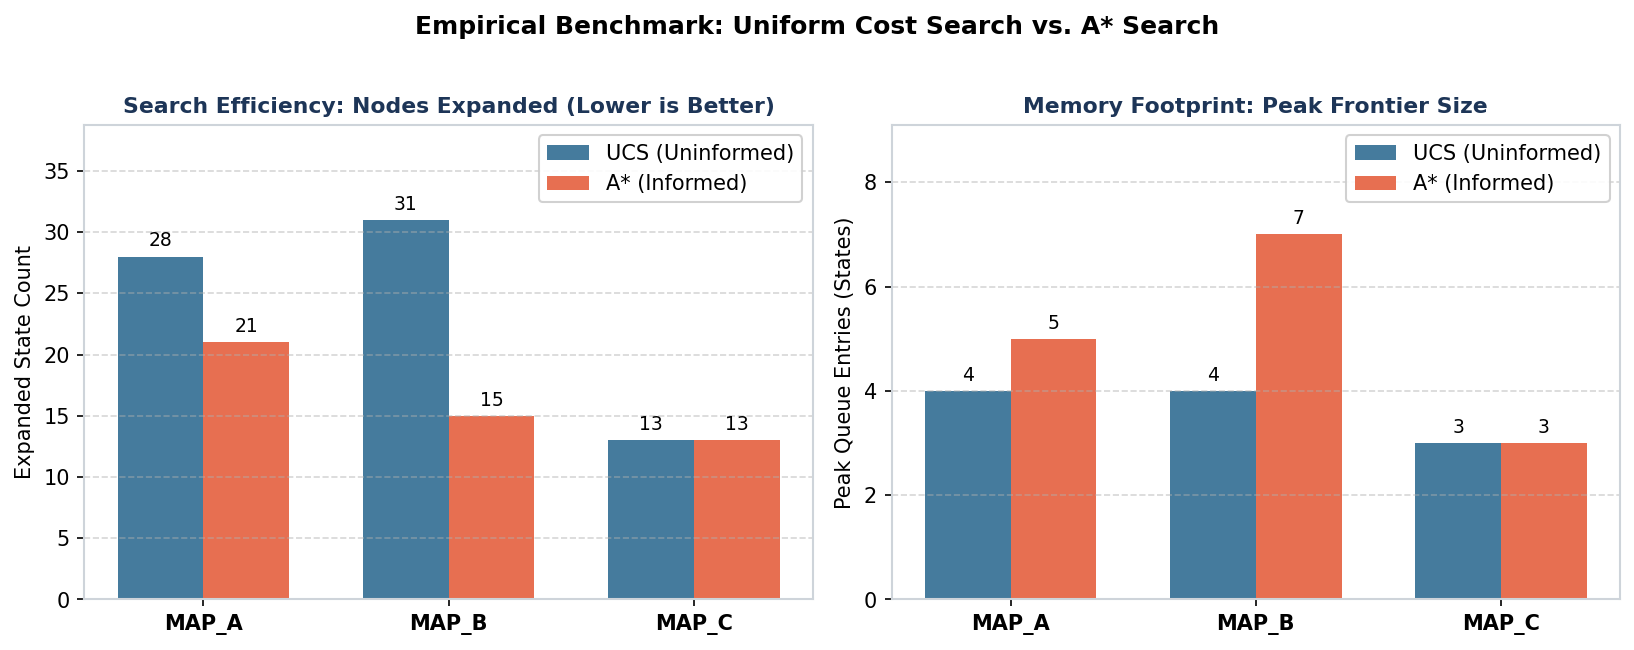

In [15]:
maps = ['MAP_A', 'MAP_B', 'MAP_C']
x = np.arange(len(maps))
width = 0.35

ucs_exp = [res_ucs_a.nodes_expanded, res_ucs_b.nodes_expanded, res_ucs_c.nodes_expanded]
astar_exp = [res_astar_a.nodes_expanded, res_astar_b.nodes_expanded, res_astar_c.nodes_expanded]

ucs_front = [res_ucs_a.max_frontier_size, res_ucs_b.max_frontier_size, res_ucs_c.max_frontier_size]
astar_front = [res_astar_a.max_frontier_size, res_astar_b.max_frontier_size, res_astar_c.max_frontier_size]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150)

# 1. Nodes Expanded (Search Efficiency)
r1 = ax1.bar(x - width/2, ucs_exp, width, label='UCS (Uninformed)', color='#457B9D')
r2 = ax1.bar(x + width/2, astar_exp, width, label='A* (Informed)', color='#E76F51')
ax1.set_title('Search Efficiency: Nodes Expanded (Lower is Better)', fontweight='bold', fontsize=10.5, color='#1D3557')
ax1.set_ylabel('Expanded State Count')
ax1.set_xticks(x)
ax1.set_xticklabels(maps, fontweight='bold')
ax1.set_ylim(0, max(ucs_exp + astar_exp) * 1.25)
ax1.bar_label(r1, padding=3, fontsize=9)
ax1.bar_label(r2, padding=3, fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', framealpha=0.9)

# 2. Peak Frontier Size (Memory Footprint)
r3 = ax2.bar(x - width/2, ucs_front, width, label='UCS (Uninformed)', color='#457B9D')
r4 = ax2.bar(x + width/2, astar_front, width, label='A* (Informed)', color='#E76F51')
ax2.set_title('Memory Footprint: Peak Frontier Size', fontweight='bold', fontsize=10.5, color='#1D3557')
ax2.set_ylabel('Peak Queue Entries (States)')
ax2.set_xticks(x)
ax2.set_xticklabels(maps, fontweight='bold')
ax2.set_ylim(0, max(ucs_front + astar_front) * 1.30)
ax2.bar_label(r3, padding=3, fontsize=9)
ax2.bar_label(r4, padding=3, fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)
ax2.legend(loc='upper right', framealpha=0.9)

plt.suptitle('Empirical Benchmark: Uniform Cost Search vs. A* Search', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Algorithm Selection and Deployment Justification

### Recommendation: A* Search

Based on our benchmark results and the theoretical properties of the algorithms, **A* Search with the Manhattan distance heuristic is the better choice for the warehouse delivery robot.**

#### Key Reasons:
1. **Fewer Node Expansions:** A* cut node expansions by **25.0%** on `MAP_A` (21 vs. 28) and **51.6%** on `MAP_B` (15 vs. 31). On larger warehouse layouts with hundreds or thousands of cells, this reduction in search effort saves substantial computation time.
2. **Guaranteed Path Optimality:** Because the Manhattan distance heuristic is admissible and consistent on a 4-connected grid where step cost is at least 1, A* achieves the exact same optimal path cost as UCS.
3. **Safe Termination:** When no path to the goal exists (`MAP_C`), A* terminates cleanly without getting stuck in infinite loops.
4. **Practical Suitability:** In a real robot where path planning may need to run frequently as obstacles change, expanding fewer nodes means faster path calculation and less processor load.

## 12. Conclusion

From this project, we can draw three main conclusions:
1. **The shortest path is not always the cheapest:** On `MAP_B`, an unweighted search looking only at step count would pick the direct 8-move route with a high cost of 22. Both UCS and A* correctly chose the 12-move detour around the wall because it had a much lower total cost of 12.
2. **Heuristic guidance significantly reduces search effort:** Using an admissible Manhattan distance heuristic allowed A* to find the exact same optimal paths as UCS while expanding 25.0% to 51.6% fewer nodes on solvable maps.
3. **Both algorithms are complete and reliable:** Both UCS and A* successfully found optimal paths when available and safely terminated when the goal was blocked by an impassable barrier on `MAP_C`.